<a href="https://colab.research.google.com/github/vzKato/Mini-project_Cafe_Aurora/blob/main/Additional_exercises_Cafe_Aurora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import files

# Subir archivo CSV
# Upload CSV file
uploaded = files.upload()

# Leer el CSV en un DataFrame
# Read the CSV into a DataFrame
df = pd.read_csv("ddbb_cafe_aurora.csv")

# Visualizar las primeras filas
# Display the first few rows
df.head()

Saving ddbb_cafe_aurora.csv to ddbb_cafe_aurora.csv


,Unnamed: 0,id_venta,fecha,ciudad,producto,cantidad,precio_unitario,total
0,0,1,2025-06-13,Querétaro,Espresso,3,35,105
1,1,2,2025-03-04,CDMX,Cappuccino,1,50,50
2,2,3,2025-06-23,Puebla,Chai Latte,1,58,58
3,3,4,2025-06-01,Querétaro,Americano,1,40,40
4,4,5,2025-01-24,CDMX,Cappuccino,5,50,250


In [26]:
# Instalación pandasql
# Installing pandasql
!pip install pandasql -q

from pandasql import sqldf

# Función auxiliar para ejecutar SQL sobre nuestros DataFrames
# Helper function for executing SQL on our DataFrames
consulta = lambda q: sqldf(q,globals())

# Consulta SQL: top 3 productos con más ingresos
# SQL Query: Top 3 Highest-Revenue Products
query = """
SELECT producto,
  SUM(total) AS ingresos_totales,
  SUM(cantidad) AS unidades_vendidas
FROM df
GROUP BY producto
ORDER BY ingresos_totales DESC
LIMIT 3
"""

resultado = consulta(query)
print(resultado)

  Preparing metadata (setup.py) ... done
     producto  ingresos_totales  unidades_vendidas
0  Chai Latte             32248                556
1       Latte             28875                525
2       Mocha             28800                480


Calcula el total de ingresos de todas las ventas generadas usando un bucle.

Calculate the total revenue from all sales using a loop.


In [23]:
ingresos_totales = 0
for v in df["total"]:
  ingresos_totales +=v
print("Ingresos totales: $", ingresos_totales)

Ingresos totales: $ 147828


Cuenta cuántas ventas se hicieron en la ciudad de Querétaro.

Count how many sales were made in the city of Querétaro.

In [24]:
contador_qro = 0
for v in df["ciudad"]:
  if v == "Querétaro":
    contador_qro +=1
print("Ventas realizadas en Querétaro:", contador_qro)

Ventas realizadas en Querétaro: 206


Crea una lista llamada `productos_caros` que contenga solo los nombres de productos cuyo precio sea mayor a 50 pesos.

Create a list called `productos_caros` containing only the names of products whose price is greater than 50 pesos.

In [25]:
productos_caros = []
for index, fila in df.iterrows():
  if fila["precio_unitario"] > 50:
    productos_caros.append(fila["producto"])

# Eliminar duplicados
# Remove duplicates
productos_caros = list(set(productos_caros))

print("Productos con precio mayor a $50:", productos_caros)

Productos con precio mayor a $50: ['Latte', 'Mocha', 'Chai Latte']


Calcula el ticket promedio (valor promedio de la columna total) de todas las ventas

Calculate the average ticket (average value of the “Total” column) for all sales

In [27]:
ticket_promedio = df["total"].mean()
print("Ticket promedio: $", round(ticket_promedio,2))

Ticket promedio: $ 147.83


Obtener la cantidad de ventas realizadas en cada ciudad, ordenadas de mayor a menor

Get the number of sales made in each city, sorted from highest to lowest

In [28]:
query = """

SELECT ciudad,
  COUNT(*) AS num_ventas
FROM df
GROUP BY ciudad
ORDER BY num_ventas DESC
"""

print(consulta(query))

        ciudad  num_ventas
0  Guadalajara         210
1    Querétaro         206
2       Puebla         202
3    Monterrey         201
4         CDMX         181


Crear gráfico de barras horizontales que muestren las unidades vendidas por producto

Create a horizontal bar chart showing the number of units sold by product

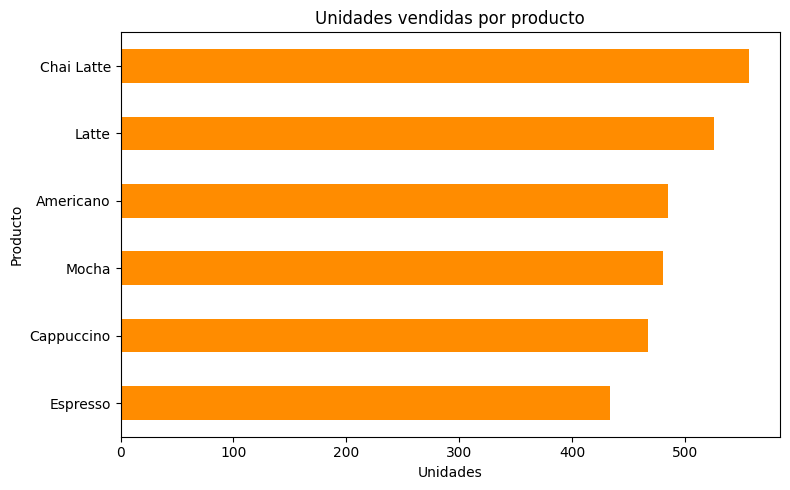

In [32]:
import matplotlib.pyplot as plt

unidades_producto = df.groupby("producto")["cantidad"].sum().sort_values()

plt.figure(figsize=(8,5))
unidades_producto.plot(kind="barh", color="darkorange")
plt.title("Unidades vendidas por producto")
plt.xlabel("Unidades")
plt.ylabel("Producto")
plt.tight_layout()